# Universidad de Buenos Aires
# Aprendizaje Profundo - TP3
# Cohorte 23 - 1er bimestre 2026

## Alumno: Agustín Jesús Vazquez (e2301)


# **CLASIFICADOR DE EMOCIONES**

El objetivo de este trabajo es construir una red neuronal convolucional (CNN) utilizando Pytorch, capaz de clasificar emociones humanas a partir de imágenes faciales. El clasificador deberá identificar una de las 7 emociones básicas: alegría, tristeza, enojo, miedo, sorpresa, disgusto y seriedad. El dataset se encuentra en este link: https://drive.google.com/file/d/1aPHE00zkDhEV1waJKhaOJMdN6-lUc0iT/view?usp=sharing

Les recomiendo usar el siguiente código para poder obtener las imágenes fácilmente desde ese link. Pero son libres de descargar las imágenes como mejor les parezca.

In [4]:
import os

# El dataset ya fue descargado y extraído localmente.
# Buscar la carpeta automáticamente según el directorio de trabajo.
for _base in ['.', 'Trabajo_Practico_3']:
    _candidate = os.path.join(_base, 'datos_zip', 'dataset_emociones')
    if os.path.isdir(_candidate):
        DATASET_ROOT_TRAIN = os.path.join(_candidate, 'train')
        DATASET_ROOT_VAL   = os.path.join(_candidate, 'validation')
        print(f"Dataset encontrado en: {os.path.abspath(_candidate)}")
        break
else:
    raise FileNotFoundError(
        "No se encontró el dataset. Verificar que exista "
        "'datos_zip/dataset_emociones/' en la carpeta del TP."
    )

print(f"Train: {os.path.abspath(DATASET_ROOT_TRAIN)}")
print(f"Val:   {os.path.abspath(DATASET_ROOT_VAL)}")

Dataset encontrado en: c:\Users\agust\AP_Vazquez_Workspace\Trabajo_Practico_3\datos_zip\dataset_emociones
Train: c:\Users\agust\AP_Vazquez_Workspace\Trabajo_Practico_3\datos_zip\dataset_emociones\train
Val:   c:\Users\agust\AP_Vazquez_Workspace\Trabajo_Practico_3\datos_zip\dataset_emociones\validation


In [5]:
# ── Imports y configuración global ───────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from PIL import Image
import cv2

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo disponible: {device}")

# Constantes globales
IMG_SIZE   = 48       # tamaño estándar FER-2013
NUM_CLASES = 7
EMOCIONES  = ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']

Dispositivo disponible: cpu


Imagen de muestra  →  Tamaño: (100, 100)  |  Modo: RGB
Total train: 12271  |  Total val: 3068


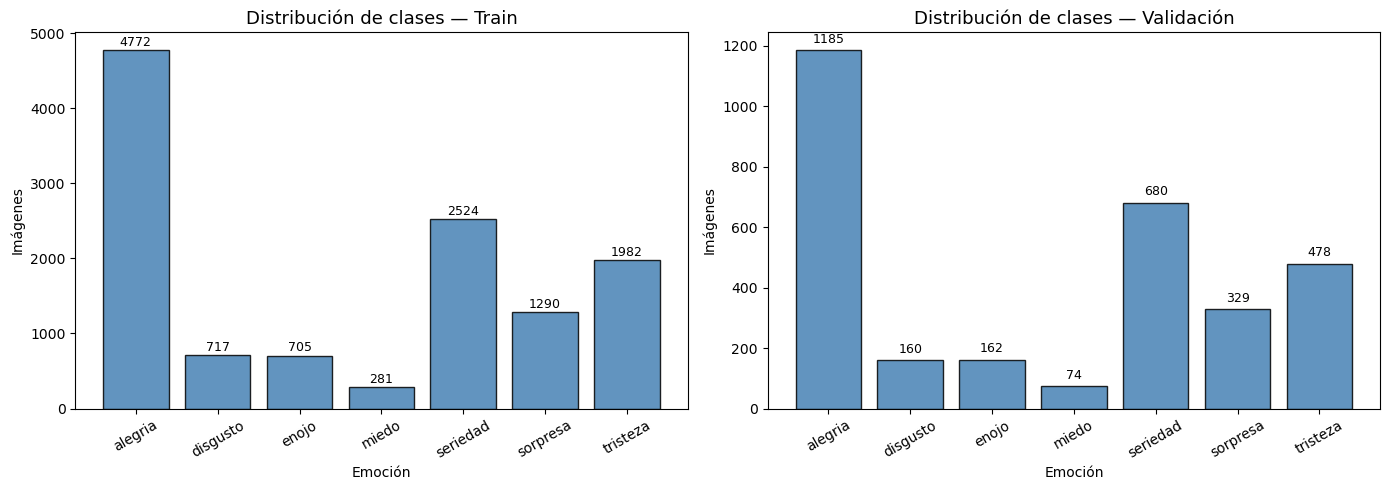


Clases detectadas: ['alegria', 'disgusto', 'enojo', 'miedo', 'seriedad', 'sorpresa', 'tristeza']
Batch size: 64  |  Batches train: 192  |  Batches val: 48


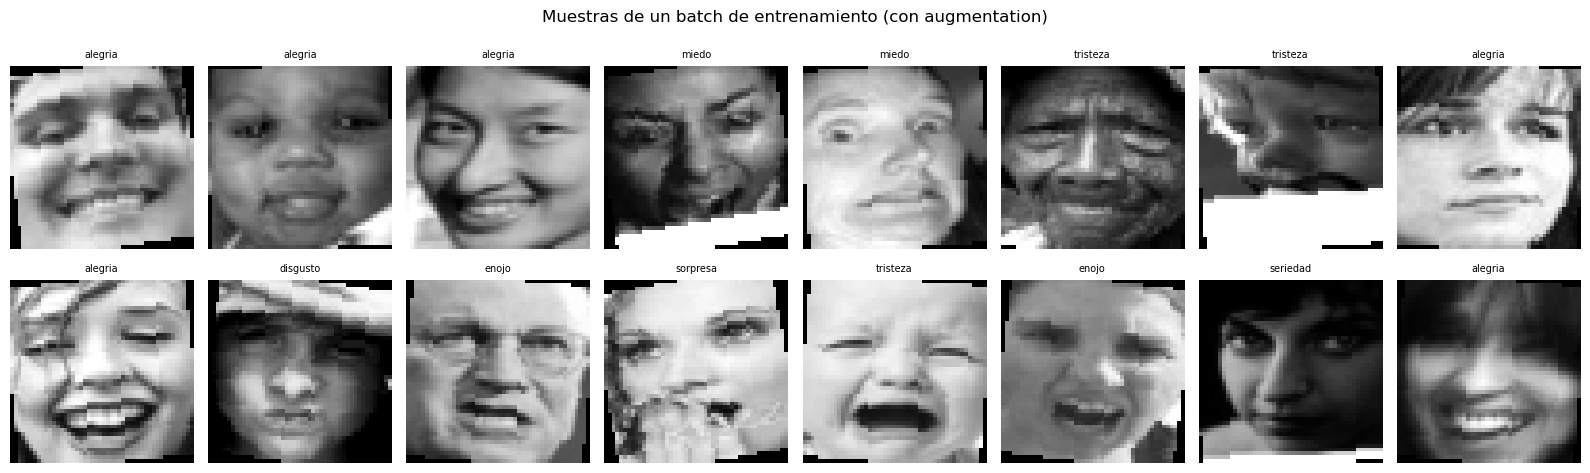

In [6]:
# ── 1.1 Análisis: tamaño de imagen y distribución de clases ──────────────────
def contar_imagenes(root):
    conteo = {}
    for clase in sorted(os.listdir(root)):
        ruta = os.path.join(root, clase)
        if os.path.isdir(ruta):
            n = len([f for f in os.listdir(ruta)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            conteo[clase] = n
    return conteo

conteo_train = contar_imagenes(DATASET_ROOT_TRAIN)
conteo_val   = contar_imagenes(DATASET_ROOT_VAL)

# Inspeccionar una imagen de muestra para conocer tamaño y modo
primera_clase = sorted(os.listdir(DATASET_ROOT_TRAIN))[0]
primera_img   = os.listdir(os.path.join(DATASET_ROOT_TRAIN, primera_clase))[0]
img_muestra   = Image.open(os.path.join(DATASET_ROOT_TRAIN, primera_clase, primera_img))
print(f"Imagen de muestra  →  Tamaño: {img_muestra.size}  |  Modo: {img_muestra.mode}")
print(f"Total train: {sum(conteo_train.values())}  |  Total val: {sum(conteo_val.values())}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, conteo, titulo in zip(axes, [conteo_train, conteo_val], ['Train', 'Validación']):
    clases  = list(conteo.keys())
    valores = list(conteo.values())
    bars = ax.bar(clases, valores, color='steelblue', edgecolor='black', alpha=0.85)
    ax.set_title(f'Distribución de clases — {titulo}', fontsize=13)
    ax.set_xlabel('Emoción')
    ax.set_ylabel('Imágenes')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 15, str(v),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# ── 1.2 Decisiones de preprocesamiento ───────────────────────────────────────
# • Tamaño 48×48: resolución estándar para reconocimiento facial de emociones.
#   Las imágenes ya son cuadradas o muy cercanas a ello; no se pierde info relevante.
# • Escala de grises: las emociones se detectan por geometría facial (contornos,
#   posición de cejas, boca), no por color. Reducir a 1 canal baja el costo
#   computacional sin perder señal discriminativa.
# • Normalización a [-1, 1]: media=0.5, std=0.5 por canal. Acelera la convergencia
#   y estabiliza el entrenamiento con BatchNorm.
# • Data augmentation solo en train:
#   - Flip horizontal: la expresión facial es simétricamente válida.
#   - Rotación ±10°: simula variación natural de pose leve.
#   - Jitter de brillo/contraste: simula condiciones de iluminación distintas.
# • WeightedRandomSampler: el dataset tiene desbalance (disgust y fear son pocas
#   muestras); samplear con peso inverso a la frecuencia mejora la cobertura de
#   clases minoritarias.

transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# ── 1.3 Datasets y DataLoaders ────────────────────────────────────────────────
dataset_train = ImageFolder(root=DATASET_ROOT_TRAIN, transform=transform_train)
dataset_val   = ImageFolder(root=DATASET_ROOT_VAL,   transform=transform_val)

print(f"\nClases detectadas: {dataset_train.classes}")

# WeightedRandomSampler para balancear clases en train
conteos_clases = np.array([conteo_train.get(c, 1) for c in dataset_train.classes])
pesos_clases   = 1.0 / conteos_clases
pesos_muestras = np.array([pesos_clases[label] for _, label in dataset_train.samples])
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(pesos_muestras),
    num_samples=len(dataset_train),
    replacement=True,
)

BATCH_SIZE   = 64
loader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=0, pin_memory=True)
loader_val   = DataLoader(dataset_val,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Batch size: {BATCH_SIZE}  |  "
      f"Batches train: {len(loader_train)}  |  Batches val: {len(loader_val)}")

# Verificación visual: un batch de muestra
imagenes_muestra, etiquetas_muestra = next(iter(loader_train))
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for idx, ax in enumerate(axes.flat):
    img = imagenes_muestra[idx].squeeze().numpy()
    img = img * 0.5 + 0.5           # des-normalizar a [0, 1]
    ax.imshow(img, cmap='gray')
    ax.set_title(dataset_train.classes[etiquetas_muestra[idx]], fontsize=7)
    ax.axis('off')
plt.suptitle('Muestras de un batch de entrenamiento (con augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# ── 2.1 Arquitectura de la CNN ────────────────────────────────────────────────
# Diseño: 4 bloques convolucionales con Batch Normalization y MaxPooling,
# seguidos de un clasificador FC con Dropout.
#
# Decisiones de diseño:
# • Kernels 3×3: buena relación campo receptivo / parámetros; estándar en literatura.
# • Doble conv por bloque: incrementa profundidad sin aumentar el stride abruptamente.
# • BatchNorm2d: normaliza activaciones → acelera convergencia, reduce sensibilidad al lr.
# • ReLU: no linealidad no saturante, evita vanishing gradient.
# • MaxPool 2×2: reduce dimensiones espaciales a la mitad conservando características.
# • Dropout2d (convolucional) + Dropout (FC): regularización, reduce sobreajuste.
# • AdaptiveAvgPool en bloque 4: hace la red robusta ante variaciones de IMG_SIZE.
# • Label smoothing 0.1 en la loss: suaviza las etiquetas duras, mejora generalización.
# • Activación final: ninguna (CrossEntropyLoss aplica LogSoftmax internamente).

class EmotionCNN(nn.Module):
    def __init__(self, num_classes: int = 7, in_channels: int = 1):
        super().__init__()

        def conv_block(in_ch, out_ch, dropout=0.25):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
                nn.Dropout2d(dropout),
            )

        self.bloque1 = conv_block(in_channels, 32)   # 48→24
        self.bloque2 = conv_block(32, 64)             # 24→12
        self.bloque3 = conv_block(64, 128)            # 12→6
        self.bloque4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((3, 3)),             # 6→3 (robusto al tamaño)
            nn.Dropout2d(0.25),
        )
        self.clasificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.bloque1(x)
        x = self.bloque2(x)
        x = self.bloque3(x)
        x = self.bloque4(x)
        return self.clasificador(x)


modelo = EmotionCNN(num_classes=NUM_CLASES, in_channels=1).to(device)
print(modelo)

total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"\nParámetros entrenables: {total_params:,}")

# ── 2.2 Función de costo, optimizador y scheduler ────────────────────────────
# • CrossEntropyLoss con label_smoothing=0.1: penaliza predicciones demasiado
#   confiadas, mejora calibración y generalización en datasets desbalanceados.
# • Adam (lr=1e-3, weight_decay=1e-4): convergencia rápida y estable para CNNs.
#   Weight decay actúa como L2 regularization sobre los pesos.
# • ReduceLROnPlateau: reduce el lr a la mitad si val_loss no mejora por 5 épocas,
#   evitando oscilaciones en las etapas finales del entrenamiento.

criterio    = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizador = optim.Adam(modelo.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizador, mode='min', factor=0.5, patience=5, verbose=True
)

# ── 2.3 Loop de entrenamiento ─────────────────────────────────────────────────
NUM_EPOCAS = 50

historial = {k: [] for k in
             ['train_loss', 'val_loss', 'train_acc', 'val_acc', 'train_f1', 'val_f1']}

mejor_val_loss = float('inf')
mejor_pesos    = None


def una_epoca(loader, entrenar=True):
    """Ejecuta un epoch completo. Devuelve (loss, acc, f1)."""
    if entrenar:
        modelo.train()
    else:
        modelo.eval()

    loss_total, correctos, total = 0.0, 0, 0
    preds_ep, labels_ep = [], []
    ctx = torch.enable_grad() if entrenar else torch.no_grad()

    with ctx:
        for imgs, etqs in loader:
            imgs, etqs = imgs.to(device), etqs.to(device)
            if entrenar:
                optimizador.zero_grad()
            logits = modelo(imgs)
            loss   = criterio(logits, etqs)
            if entrenar:
                loss.backward()
                nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
                optimizador.step()

            loss_total += loss.item() * imgs.size(0)
            preds       = logits.argmax(dim=1)
            correctos  += (preds == etqs).sum().item()
            total      += imgs.size(0)
            preds_ep.extend(preds.cpu().numpy())
            labels_ep.extend(etqs.cpu().numpy())

    ep_loss = loss_total / total
    ep_acc  = correctos  / total
    ep_f1   = f1_score(labels_ep, preds_ep, average='weighted', zero_division=0)
    return ep_loss, ep_acc, ep_f1


for epoca in range(1, NUM_EPOCAS + 1):
    t_loss, t_acc, t_f1 = una_epoca(loader_train, entrenar=True)
    v_loss, v_acc, v_f1 = una_epoca(loader_val,   entrenar=False)

    scheduler.step(v_loss)

    if v_loss < mejor_val_loss:
        mejor_val_loss = v_loss
        mejor_pesos    = {k: v.clone() for k, v in modelo.state_dict().items()}

    for key, val in zip(historial, [t_loss, v_loss, t_acc, v_acc, t_f1, v_f1]):
        historial[key].append(val)

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:3d}/{NUM_EPOCAS}  |  "
              f"Loss T/V: {t_loss:.4f}/{v_loss:.4f}  |  "
              f"Acc T/V: {t_acc:.4f}/{v_acc:.4f}  |  "
              f"F1 T/V: {t_f1:.4f}/{v_f1:.4f}")

# Restaurar mejores pesos
modelo.load_state_dict(mejor_pesos)
print(f"\nMejor val_loss alcanzado: {mejor_val_loss:.4f}")
print("Pesos del mejor modelo restaurados correctamente.")

EmotionCNN(
  (bloque1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (bloque2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace

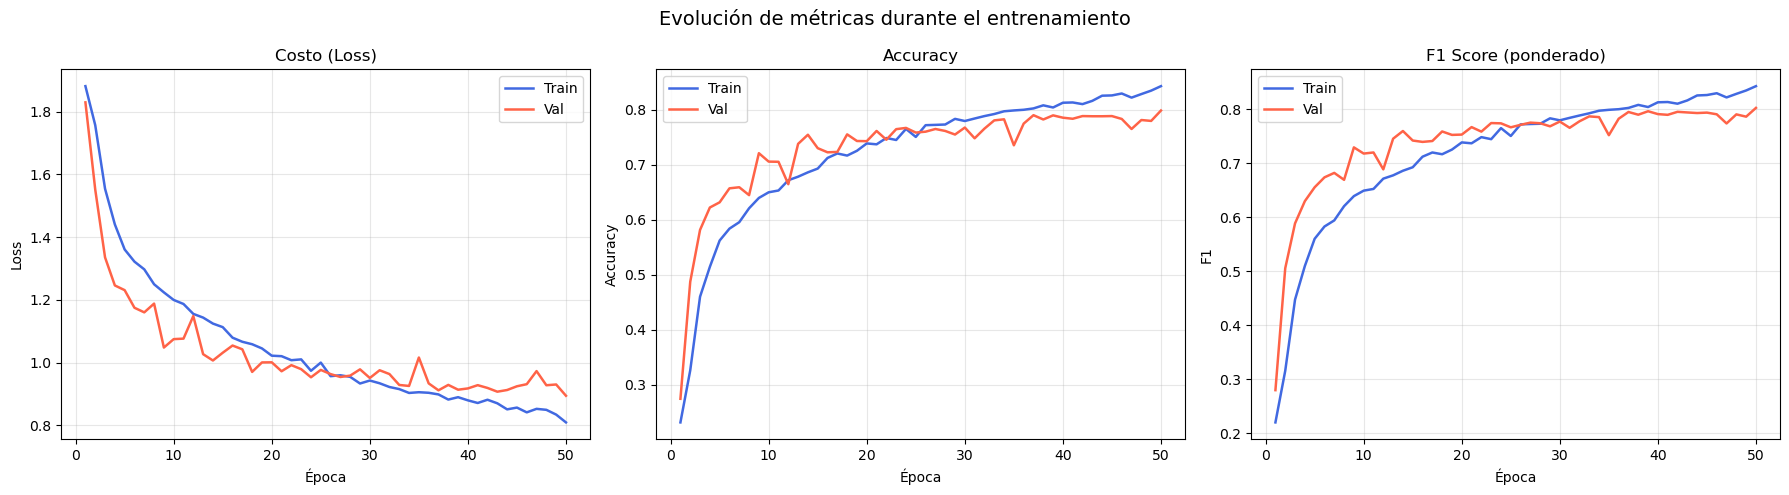

Accuracy final (val) : 0.7986  (79.86%)
F1 Score  final (val): 0.8023

Classification Report:
              precision    recall  f1-score   support

     alegria       0.94      0.87      0.90      1185
    disgusto       0.43      0.53      0.47       160
       enojo       0.66      0.81      0.73       162
       miedo       0.59      0.61      0.60        74
    seriedad       0.79      0.76      0.77       680
    sorpresa       0.80      0.83      0.82       329
    tristeza       0.74      0.77      0.75       478

    accuracy                           0.80      3068
   macro avg       0.71      0.74      0.72      3068
weighted avg       0.81      0.80      0.80      3068



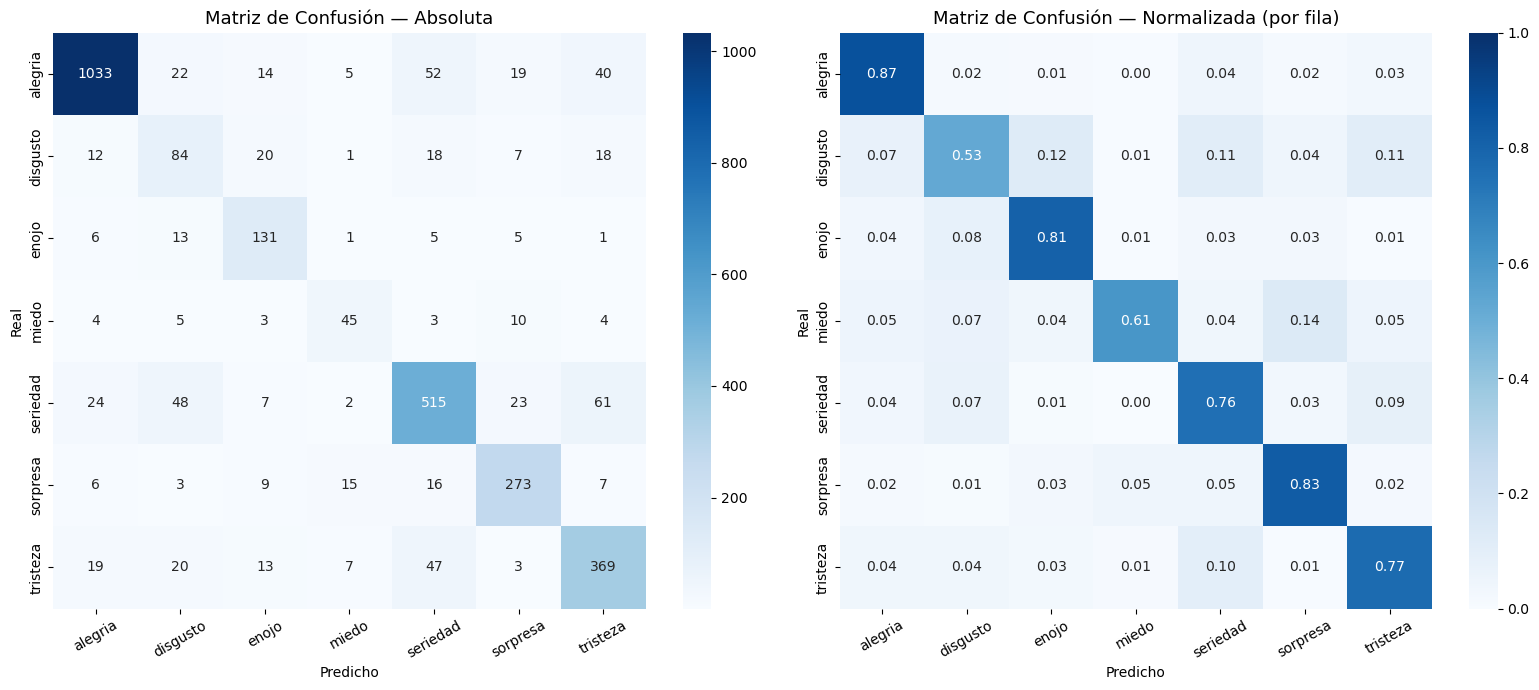

In [8]:
# ── 3.1 Curvas de entrenamiento ───────────────────────────────────────────────
epocas = range(1, len(historial['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metricas = [
    ('train_loss', 'val_loss', 'Costo (Loss)',          'Loss'),
    ('train_acc',  'val_acc',  'Accuracy',               'Accuracy'),
    ('train_f1',   'val_f1',   'F1 Score (ponderado)',   'F1'),
]
for ax, (tk, vk, titulo, ylabel) in zip(axes, metricas):
    ax.plot(epocas, historial[tk], label='Train', color='royalblue', linewidth=1.8)
    ax.plot(epocas, historial[vk], label='Val',   color='tomato',    linewidth=1.8)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Época')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Evolución de métricas durante el entrenamiento', fontsize=14)
plt.tight_layout()
plt.show()

# ── 3.2 Predicciones finales en validación ────────────────────────────────────
modelo.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, etqs in loader_val:
        logits = modelo(imgs.to(device))
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(etqs.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc_final = accuracy_score(all_labels, all_preds)
f1_final  = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Accuracy final (val) : {acc_final:.4f}  ({acc_final*100:.2f}%)")
print(f"F1 Score  final (val): {f1_final:.4f}\n")

# ── 3.3 Classification Report ─────────────────────────────────────────────────
nombres_clases = dataset_train.classes
print("=" * 60)
print("Classification Report:")
print("=" * 60)
print(classification_report(all_labels, all_preds,
                             target_names=nombres_clases, zero_division=0))

# ── 3.4 Matrices de confusión ─────────────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=nombres_clases, yticklabels=nombres_clases)
axes[0].set_title('Matriz de Confusión — Absoluta', fontsize=13)
axes[0].set_xlabel('Predicho')
axes[0].set_ylabel('Real')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=nombres_clases, yticklabels=nombres_clases,
            vmin=0, vmax=1)
axes[1].set_title('Matriz de Confusión — Normalizada (por fila)', fontsize=13)
axes[1].set_xlabel('Predicho')
axes[1].set_ylabel('Real')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [9]:
# ── 4. Prueba con imágenes personales (sin detección facial previa) ───────────
# Colocar las 12+ imágenes en /content/mis_imagenes/
# (pueden subirse manualmente o con files.upload())

CARPETA_IMAGENES = '/content/mis_imagenes'
os.makedirs(CARPETA_IMAGENES, exist_ok=True)

nombres_clases = dataset_train.classes


def predecir(img_pil: Image.Image) -> tuple[np.ndarray, str]:
    """Aplica transform_val, corre el modelo y devuelve (probs, clase_ganadora)."""
    modelo.eval()
    tensor = transform_val(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(modelo(tensor), dim=1).squeeze().cpu().numpy()
    return probs, nombres_clases[probs.argmax()]


def graficar_resultado(ax_orig, ax_prep, ax_bar,
                       img_orig: Image.Image, probs: np.ndarray,
                       clase: str, titulo: str = '') -> None:
    """Dibuja: imagen original | imagen preprocesada | barras de scores."""
    # Original
    ax_orig.imshow(img_orig)
    ax_orig.set_title(f'Original\n{titulo}', fontsize=8)
    ax_orig.axis('off')

    # Preprocesada (des-normalizar para visualizar)
    tensor_vis = transform_val(img_orig) * 0.5 + 0.5
    img_prep   = tensor_vis.squeeze().numpy()
    ax_prep.imshow(img_prep, cmap='gray')
    ax_prep.set_title(f'Preprocesada\n({IMG_SIZE}×{IMG_SIZE} gris)', fontsize=8)
    ax_prep.axis('off')

    # Barras de scores
    colores = ['tomato' if p == probs.max() else 'steelblue' for p in probs]
    ax_bar.barh(nombres_clases, probs * 100, color=colores,
                edgecolor='black', alpha=0.85)
    ax_bar.set_xlim(0, 110)
    ax_bar.set_xlabel('Score (%)', fontsize=8)
    ax_bar.set_title(f'Pred: {clase}', fontsize=9, fontweight='bold')
    ax_bar.tick_params(axis='y', labelsize=7)
    for i, p in enumerate(probs):
        ax_bar.text(p * 100 + 1, i, f'{p*100:.1f}%', va='center', fontsize=6)


# Cargar imágenes de la carpeta
EXTENSIONES   = ('.jpg', '.jpeg', '.png', '.webp')
archivos      = sorted([f for f in os.listdir(CARPETA_IMAGENES)
                        if f.lower().endswith(EXTENSIONES)])

if not archivos:
    print("⚠  No se encontraron imágenes en", CARPETA_IMAGENES)
    print("   Subí al menos 12 imágenes (una por emoción) y volvé a ejecutar.")
else:
    n = len(archivos)
    print(f"Se encontraron {n} imágenes.")

    resultados_sin_recorte = {}

    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    for i, archivo in enumerate(archivos):
        ruta     = os.path.join(CARPETA_IMAGENES, archivo)
        img_orig = Image.open(ruta).convert('RGB')
        probs, clase = predecir(img_orig)
        resultados_sin_recorte[archivo] = {'probs': probs, 'clase': clase}
        graficar_resultado(axes[i, 0], axes[i, 1], axes[i, 2],
                           img_orig, probs, clase, titulo=archivo)

    plt.suptitle('Sección 4 — Imágenes personales (sin recorte facial)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    print("\nResumen de predicciones (sin recorte facial):")
    print(f"{'Imagen':<32} {'Predicción':<12} {'Score máx':>10}")
    print("-" * 58)
    for archivo, r in resultados_sin_recorte.items():
        print(f"{archivo:<32} {r['clase']:<12} {r['probs'].max()*100:>9.1f}%")

# ── Conclusiones preliminares ─────────────────────────────────────────────────
# TODO: redactar observaciones sobre los resultados obtenidos.
# Considerar: ¿el modelo clasifica correctamente las emociones "fáciles" (alegría,
# sorpresa)? ¿Cuáles confunde? ¿Cómo afecta la escala de la cara en la imagen?

⚠  No se encontraron imágenes en /content/mis_imagenes
   Subí al menos 12 imágenes (una por emoción) y volvé a ejecutar.


## 1. Preprocesamiento de Datos

Antes de entrenar el modelo, se debe analizar qué tipo de preprocesamiento se debe aplicar a las imágenes. Para esto, se puede considerar uno o más aspectos como:

- Tamaño
- Relación de aspecto
- Color o escala de grises
- Cambio de dimensionalidad
- Normalización
- Balanceo de datos
- Data augmentation
- etc.

Sean criteriosos y elijan solo las técnicas que consideren pertinentes para este caso de uso en específico.

Recomendación: usar `torchvision.transforms` para facilitar el preprocesamiento. Lean su documentación si tienen dudas: https://docs.pytorch.org/vision/0.14/transforms.html



In [10]:
# ── 5. Prueba con detección de rostros + comparación con sección 4 ───────────

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)


def recortar_rostro(ruta: str,
                    scale_factor: float = 1.1,
                    min_neighbors: int = 6) -> tuple[Image.Image | None, bool]:
    """Detecta y recorta el rostro más prominente.

    Devuelve (PIL Image RGB recortada, rostro_detectado).
    Si no se detecta rostro, devuelve (None, False).
    """
    imagen = cv2.imread(ruta)
    if imagen is None:
        return None, False
    gray  = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=scale_factor, minNeighbors=min_neighbors
    )
    if len(faces) == 0:
        return None, False

    (x, y, w, h) = faces[0]
    cx, cy = x + w // 2, y + h // 2
    lado   = max(w, h)
    mitad  = lado // 2
    x1 = max(cx - mitad, 0);       y1 = max(cy - mitad, 0)
    x2 = min(cx + mitad, imagen.shape[1])
    y2 = min(cy + mitad, imagen.shape[0])
    recorte = cv2.cvtColor(imagen[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
    return Image.fromarray(recorte), True


if not archivos:
    print("⚠  No hay imágenes cargadas. Ejecutar primero la sección 4.")
else:
    resultados_con_recorte = {}
    sin_deteccion          = []

    n   = len(archivos)
    fig = plt.figure(figsize=(16, 4.5 * n))

    for i, archivo in enumerate(archivos):
        ruta     = os.path.join(CARPETA_IMAGENES, archivo)
        img_orig = Image.open(ruta).convert('RGB')

        rostro_pil, detectado = recortar_rostro(ruta)
        if not detectado:
            sin_deteccion.append(archivo)
            print(f"⚠  No se detectó rostro en '{archivo}' → usando imagen completa.")
            rostro_pil = img_orig

        probs, clase = predecir(rostro_pil)
        resultados_con_recorte[archivo] = {'probs': probs, 'clase': clase}

        # Visualización de 4 columnas: original | recortada | preprocesada | scores
        ax_orig = fig.add_subplot(n, 4, i * 4 + 1)
        ax_crop = fig.add_subplot(n, 4, i * 4 + 2)
        ax_prep = fig.add_subplot(n, 4, i * 4 + 3)
        ax_bar  = fig.add_subplot(n, 4, i * 4 + 4)

        ax_orig.imshow(img_orig)
        ax_orig.set_title(f'Original\n{archivo}', fontsize=7)
        ax_orig.axis('off')

        ax_crop.imshow(rostro_pil)
        label_recorte = 'Rostro recortado' if detectado else 'Sin detección\n(completa)'
        ax_crop.set_title(label_recorte, fontsize=7)
        ax_crop.axis('off')

        tensor_vis = transform_val(rostro_pil) * 0.5 + 0.5
        ax_prep.imshow(tensor_vis.squeeze().numpy(), cmap='gray')
        ax_prep.set_title(f'Preprocesada\n({IMG_SIZE}×{IMG_SIZE} gris)', fontsize=7)
        ax_prep.axis('off')

        colores = ['tomato' if p == probs.max() else 'steelblue' for p in probs]
        ax_bar.barh(nombres_clases, probs * 100, color=colores,
                    edgecolor='black', alpha=0.85)
        ax_bar.set_xlim(0, 110)
        ax_bar.set_title(f'Pred: {clase}', fontsize=9, fontweight='bold')
        ax_bar.set_xlabel('Score (%)', fontsize=8)
        ax_bar.tick_params(axis='y', labelsize=7)
        for j, p in enumerate(probs):
            ax_bar.text(p * 100 + 1, j, f'{p*100:.1f}%', va='center', fontsize=6)

    plt.suptitle('Sección 5 — Con detección facial (Haar Cascade)',
                 fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    if sin_deteccion:
        print(f"\nImágenes sin rostro detectado: {sin_deteccion}")
        print("Consejo: probar con scaleFactor más bajo (ej. 1.05) "
              "o minNeighbors más bajo (ej. 3-4).")

    # ── Tabla comparativa 4 vs 5 ──────────────────────────────────────────────
    print("\n" + "=" * 72)
    print("Comparación: Sin recorte (Sec. 4)  vs  Con recorte facial (Sec. 5)")
    print("=" * 72)
    print(f"{'Imagen':<30} {'Sec. 4':<14} {'Sec. 5':<14} {'Cambió?'}")
    print("-" * 72)
    cambios = 0
    for arch in archivos:
        r4    = resultados_sin_recorte.get(arch, {})
        r5    = resultados_con_recorte.get(arch, {})
        cambio = r4.get('clase') != r5.get('clase')
        if cambio:
            cambios += 1
        print(f"{arch:<30} {r4.get('clase','—'):<14} "
              f"{r5.get('clase','—'):<14} {'Sí  ←' if cambio else 'No'}")

    print("-" * 72)
    print(f"Predicciones que cambiaron: {cambios} / {len(archivos)}")
    print(f"Imágenes sin rostro detectado: {len(sin_deteccion)} / {len(archivos)}")

# ── Conclusiones finales ──────────────────────────────────────────────────────
# TODO: comparar los resultados de las secciones 4 y 5.
# Puntos sugeridos:
#   • ¿El recorte facial mejoró o empeoró las predicciones?
#   • ¿Para qué emociones hubo más cambios?
#   • ¿Las imágenes donde no se detectó rostro afectaron los resultados?
#   • ¿Qué limitaciones tiene Haar Cascade vs detectores modernos (MTCNN, RetinaFace)?

⚠  No hay imágenes cargadas. Ejecutar primero la sección 4.


## 2. Construcción y entrenamiento del Modelo CNN

- Construir una red neuronal convolucional con PyTorch, **sin usar modelos pre-entrenados**.
- Analizar correctamente qué funciones de activación se deben usar en cada etapa de la red, el learning rate a utilizar, la función de costo y el optimizador.
- Cosas como el número de capas, neuronas, número y tamaño de los kernels, entre otros, queda a criterio de ustedes, pero deben estar justificadas.

## 3. Evaluación del Modelo

El modelo entrenado debe ser evaluado utilizando las siguientes métricas:

- **Accuracy**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **F1 Score**:
  - Reportar el valor final en el conjunto de validación.
  - Incluir una gráfica de evolución por época para entrenamiento y validación.

- **Costo (Loss)**:
  - Mostrar una gráfica de evolución del costo por época para entrenamiento y validación.

- **Classification report**
  - Mostrar la precisión, recall y F1 score por cada clase usando `classification_report`

- **Matriz de confusión**:
  - Mostrar la matriz de confusión absoluta (valores enteros).
  - Mostrar la matriz de confusión normalizada (valores entre 0 y 1 por fila).

Se recomienda utilizar `scikit-learn` para calcular métricas como accuracy, F1 score, el Classification report y las matrices de confusión. Las visualizaciones pueden realizarse con `matplotlib` o `seaborn`, separando claramente los datos de entrenamiento y validación en las gráficas.


 ## 4. Prueba de Imágenes Nuevas
Subir al menos 12 imágenes personales de cualquier relación de aspecto (pueden usar fotos del rostro de ustedes, rostros de personas generadas por IA o imágenes stock de internet), que no formen parte del dataset de entrenamiento ni de validación.

- Debe haber al menos una imagen para cada emoción.

- Aplicar el mismo pre-procesamiento que se usó para el dataset de validation durante el entrenamiento del modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:

  - La imagen original
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Redactar conclusiones preliminares

 ## 5. Prueba de Imágenes Nuevas con Pre-procesamiento Adicional
Las 12 imágenes del punto 4, ahora serán pasadas y recortadas por un algoritmo de detección de rostros. Usen el siguiente código para realizar un pre-procesamiento inicial de la imagen y ya luego aplican el pre-procesamiento que usaron al momento de entrenar el modelo.

- Pasar las imágenes por el modelo entrenado y mostrar:
  - La imagen original
  - La imagen recortada por el algoritmo
  - La imagen pre-procesada (mismas transformaciones del entrenamiento)
  - El score asignado a cada clase (normalizado de 0 a 1 o de 0% a 100%)
  - La clase ganadora inferida por el modelo

- Comparar los resultados con el punto 4 y redactar conclusiones finales.

NOTA: Pueden adaptar el código y modificar el `scaleFactor` y el `minNeighbors` según crean conveniente para obtener mejores resultados.

In [11]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

image_path = ""

image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=6)

image_with_box = image.copy()
for (x, y, w, h) in faces:
    cv2.rectangle(image_with_box, (x, y), (x + w, y + h), (0, 255, 0), 2)

cropped_face_rgb = None
if len(faces) > 0:
    (x, y, w, h) = faces[0]
    center_x, center_y = x + w // 2, y + h // 2
    side = max(w, h)
    half_side = side // 2

    x1 = max(center_x - half_side, 0)
    y1 = max(center_y - half_side, 0)
    x2 = min(center_x + half_side, image.shape[1])
    y2 = min(center_y + half_side, image.shape[0])

    cropped_face = image[y1:y2, x1:x2]
    cropped_face_rgb = cv2.cvtColor(cropped_face, cv2.COLOR_BGR2RGB)

image_with_box_rgb = cv2.cvtColor(image_with_box, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_with_box_rgb)
ax[0].set_title("Detección")
ax[0].axis('off')

if cropped_face_rgb is not None:
    ax[1].imshow(cropped_face_rgb)
    ax[1].set_title("Rostro recortado (relación aspecto 1:1)")
    ax[1].axis('off')
else:
    ax[1].text(0.5, 0.5, 'No se detectó rostro', horizontalalignment='center', verticalalignment='center')
    ax[1].axis('off')

plt.tight_layout()
plt.show()


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
